In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

While uploading the data, read_csv operation is not able to read 'UTF-8' characters we use encoding = 'latin1' which can handle wider range of characters. Further trying different seprators didnt match with the data, Hence we'll try to read the data to identify a correct delimiter

In [3]:
with open("/content/zee-movies.dat", "r", encoding="latin1") as f:
    for _ in range(10):  # Print first 10 lines
        print(f.readline())

Movie ID::Title::Genres

1::Toy Story (1995)::Animation|Children's|Comedy

2::Jumanji (1995)::Adventure|Children's|Fantasy

3::Grumpier Old Men (1995)::Comedy|Romance

4::Waiting to Exhale (1995)::Comedy|Drama

5::Father of the Bride Part II (1995)::Comedy

6::Heat (1995)::Action|Crime|Thriller

7::Sabrina (1995)::Comedy|Romance

8::Tom and Huck (1995)::Adventure|Children's

9::Sudden Death (1995)::Action



From the above few lines of the data, we can identify '::" as the delimiter.

In [4]:
movies = pd.read_csv("/content/zee-movies.dat", encoding = 'latin1', delimiter= '::')
ratings = pd.read_csv("/content/zee-ratings.dat", encoding = 'latin1', delimiter = '::')
users = pd.read_csv("/content/zee-users.dat", encoding = 'latin1', delimiter = '::')

<ipython-input-4-3e1c90a5c276>:1: ParserWarning: Falling back to the 'python' engine because the 'c' engine does not support regex separators (separators > 1 char and different from '\s+' are interpreted as regex); you can avoid this warning by specifying engine='python'.
  movies = pd.read_csv("/content/zee-movies.dat", encoding = 'latin1', delimiter= '::')
<ipython-input-4-3e1c90a5c276>:2: ParserWarning: Falling back to the 'python' engine because the 'c' engine does not support regex separators (separators > 1 char and different from '\s+' are interpreted as regex); you can avoid this warning by specifying engine='python'.
  ratings = pd.read_csv("/content/zee-ratings.dat", encoding = 'latin1', delimiter = '::')
<ipython-input-4-3e1c90a5c276>:3: ParserWarning: Falling back to the 'python' engine because the 'c' engine does not support regex separators (separators > 1 char and different from '\s+' are interpreted as regex); you can avoid this warning by specifying engine='python'.
  

In [5]:
from posixpath import sep
movies = pd.read_csv("/content/zee-movies.dat", encoding = 'latin1', sep= '::', engine = 'python')
ratings = pd.read_csv("/content/zee-ratings.dat", encoding = 'latin1', sep = '::', engine = 'python')
users = pd.read_csv("/content/zee-users.dat", encoding = 'latin1', sep = '::', engine = 'python')

In [6]:
movies

,Movie ID,Title,Genres
0,1,Toy Story (1995),Animation|Children's|Comedy
1,2,Jumanji (1995),Adventure|Children's|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama
4,5,Father of the Bride Part II (1995),Comedy
...,...,...,...
3878,3948,Meet the Parents (2000),Comedy
3879,3949,Requiem for a Dream (2000),Drama
3880,3950,Tigerland (2000),Drama
3881,3951,Two Family House (2000),Drama


In [7]:
ratings

,UserID,MovieID,Rating,Timestamp
0,1,1193,5,978300760
1,1,661,3,978302109
2,1,914,3,978301968
3,1,3408,4,978300275
4,1,2355,5,978824291
...,...,...,...,...
1000204,6040,1091,1,956716541
1000205,6040,1094,5,956704887
1000206,6040,562,5,956704746
1000207,6040,1096,4,956715648


In [8]:
users

,UserID,Gender,Age,Occupation,Zip-code
0,1,F,1,10,48067
1,2,M,56,16,70072
2,3,M,25,15,55117
3,4,M,45,7,02460
4,5,M,25,20,55455
...,...,...,...,...,...
6035,6036,F,25,15,32603
6036,6037,F,45,1,76006
6037,6038,F,56,1,14706
6038,6039,F,45,0,01060


In [9]:
movies.rename(columns = {'Movie ID' : 'MovieID'}, inplace = True)

In [10]:
movies

,MovieID,Title,Genres
0,1,Toy Story (1995),Animation|Children's|Comedy
1,2,Jumanji (1995),Adventure|Children's|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama
4,5,Father of the Bride Part II (1995),Comedy
...,...,...,...
3878,3948,Meet the Parents (2000),Comedy
3879,3949,Requiem for a Dream (2000),Drama
3880,3950,Tigerland (2000),Drama
3881,3951,Two Family House (2000),Drama


In [11]:
df_merge = ratings.merge(movies, on='MovieID').merge(users, on = 'UserID')

In [12]:
df_merge.head()

,UserID,MovieID,Rating,Timestamp,Title,Genres,Gender,Age,Occupation,Zip-code
0,1,1193,5,978300760,One Flew Over the Cuckoo's Nest (1975),Drama,F,1,10,48067
1,1,661,3,978302109,James and the Giant Peach (1996),Animation|Children's|Musical,F,1,10,48067
2,1,914,3,978301968,My Fair Lady (1964),Musical|Romance,F,1,10,48067
3,1,3408,4,978300275,Erin Brockovich (2000),Drama,F,1,10,48067
4,1,2355,5,978824291,"Bug's Life, A (1998)",Animation|Children's|Comedy,F,1,10,48067


In [13]:
df_merge.shape

(1000209, 10)

In [14]:
df_merge.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000209 entries, 0 to 1000208
Data columns (total 10 columns):
 #   Column      Non-Null Count    Dtype 
---  ------      --------------    ----- 
 0   UserID      1000209 non-null  int64 
 1   MovieID     1000209 non-null  int64 
 2   Rating      1000209 non-null  int64 
 3   Timestamp   1000209 non-null  int64 
 4   Title       1000209 non-null  object
 5   Genres      1000209 non-null  object
 6   Gender      1000209 non-null  object
 7   Age         1000209 non-null  int64 
 8   Occupation  1000209 non-null  int64 
 9   Zip-code    1000209 non-null  object
dtypes: int64(6), object(4)
memory usage: 76.3+ MB


In [15]:
df_merge.describe()

,UserID,MovieID,Rating,Timestamp,Age,Occupation
count,1.000209e+06,1.000209e+06,1.000209e+06,1.000209e+06,1.000209e+06,1.000209e+06
mean,3.024512e+03,1.865540e+03,3.581564e+00,9.722437e+08,2.973831e+01,8.036138e+00
std,1.728413e+03,1.096041e+03,1.117102e+00,1.215256e+07,1.175198e+01,6.531336e+00
min,1.000000e+00,1.000000e+00,1.000000e+00,9.567039e+08,1.000000e+00,0.000000e+00
25%,1.506000e+03,1.030000e+03,3.000000e+00,9.653026e+08,2.500000e+01,2.000000e+00
50%,3.070000e+03,1.835000e+03,4.000000e+00,9.730180e+08,2.500000e+01,7.000000e+00
75%,4.476000e+03,2.770000e+03,4.000000e+00,9.752209e+08,3.500000e+01,1.400000e+01
max,6.040000e+03,3.952000e+03,5.000000e+00,1.046455e+09,5.600000e+01,2.000000e+01


In [16]:
df_merge.isna().sum()

,0
UserID,0
MovieID,0
Rating,0
Timestamp,0
Title,0
Genres,0
Gender,0
Age,0
Occupation,0
Zip-code,0


<Axes: ylabel='Genres'>

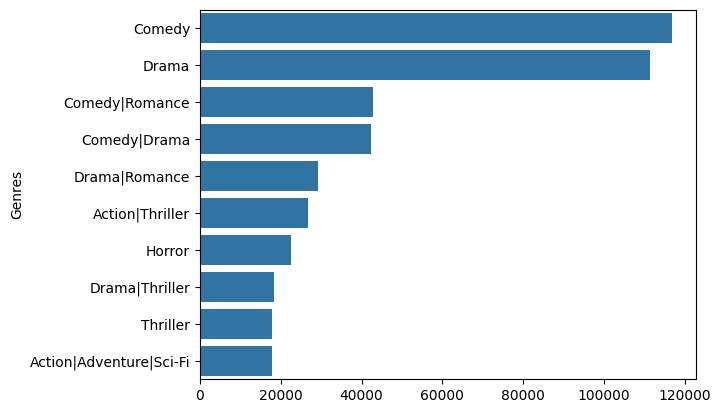

In [17]:
top_10_genres = df_merge['Genres'].value_counts().head(10)
sns.barplot(x = top_10_genres.values,  y=top_10_genres.index,)

From, the viz. Comedy genre has the most number of movies in the dataset.

<Axes: xlabel='Rating'>

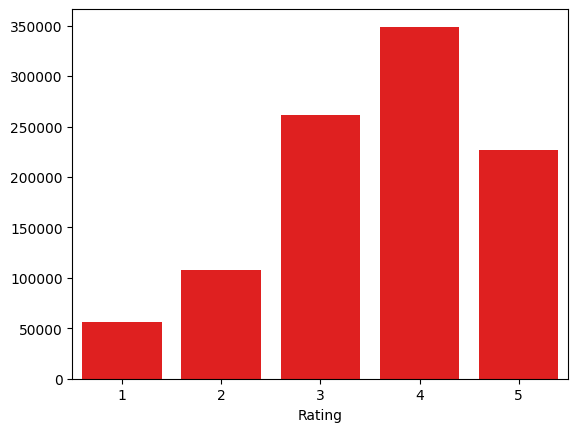

In [18]:
sns.barplot(x=df_merge['Rating'].value_counts().index, y=df_merge['Rating'].value_counts().values, color = 'r')

Based on occupation:

0: "other" or not specified

1: "academic/educator"

2: "artist"

3: "clerical/admin"

4: "college/grad student"

5: "customer service"

6: "doctor/health care"

7: "executive/managerial"

8: "farmer"

9: "homemaker"

10: "K-12 student"

11: "lawyer"

12: "programmer"

13: "retired"

14: "sales/marketing"

15: "scientist"

16: "self-employed"

17: "technician/engineer"

18: "tradesman/craftsman"

19: "unemployed"

20: "writer"

<Axes: xlabel='Occupation'>

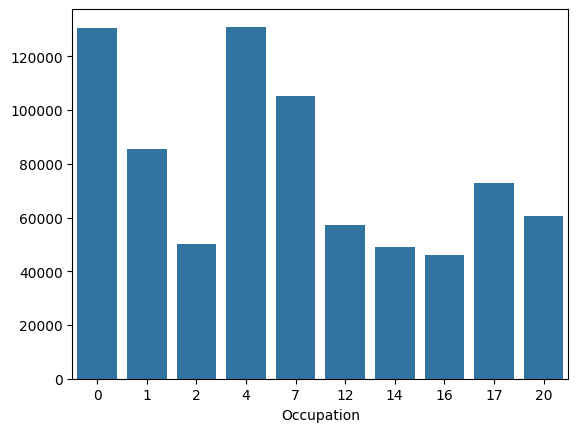

In [19]:
top_10_users_occupation = df_merge['Occupation'].value_counts().head(10)
sns.barplot(x = top_10_users_occupation.index, y = top_10_users_occupation.values)

<Axes: xlabel='Age'>

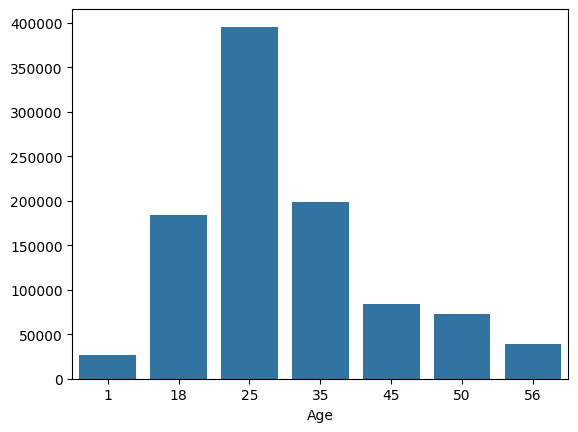

In [20]:
age_rating = df_merge.groupby('Age')['Rating'].count()
sns.barplot(x = age_rating.index, y =age_rating.values)

<Axes: xlabel='Gender'>

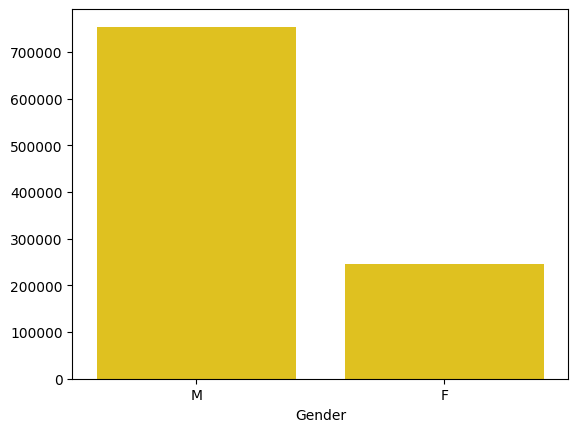

In [21]:
sns.barplot(x=df_merge['Gender'].value_counts().index,y=df_merge['Gender'].value_counts().values, color = 'gold')

In [22]:
movie_rating = df_merge.groupby('Title')['Rating'].sum()

In [23]:
top_10_movie_rating = movie_rating.sort_values(ascending=False)

In [103]:
top_10_movie_rating.head(30)

,Rating
Title,
American Beauty (1999),14800
Star Wars: Episode IV - A New Hope (1977),13321
Star Wars: Episode V - The Empire Strikes Back (1980),12836
Star Wars: Episode VI - Return of the Jedi (1983),11598
Saving Private Ryan (1998),11507
Raiders of the Lost Ark (1981),11257
"Silence of the Lambs, The (1991)",11219
"Matrix, The (1999)",11178
"Sixth Sense, The (1999)",10835


In [99]:
top_10_movie_rating.info()

<class 'pandas.core.series.Series'>
Index: 3706 entries, American Beauty (1999) to Low Life, The (1994)
Series name: Rating
Non-Null Count  Dtype
--------------  -----
3706 non-null   int64
dtypes: int64(1)
memory usage: 186.9+ KB


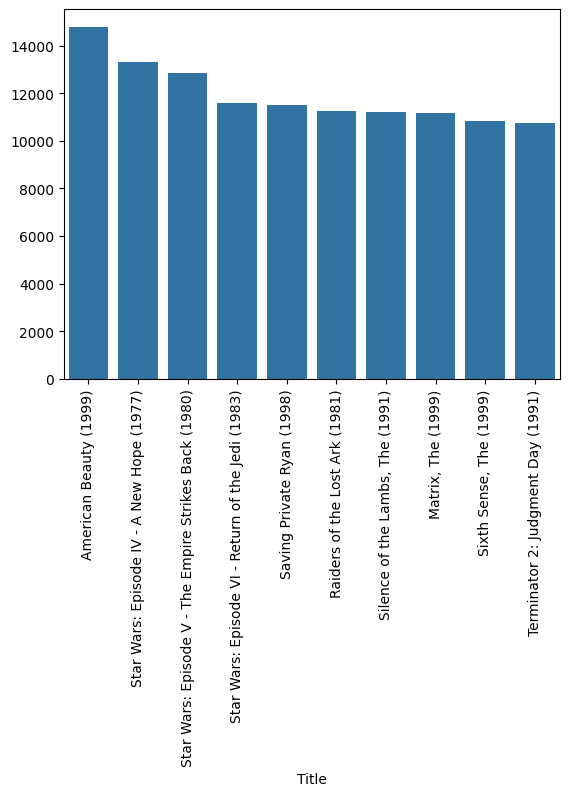

In [24]:
sns.barplot(x=top_10_movie_rating.head(10).index,y=top_10_movie_rating.head(10).values)
plt.xticks(rotation = 90)
plt.show()

In [25]:
df_merge['Year'] = df_merge['Title'].str.split('(').str[-1].str[:-1]

In [26]:
df_merge['Year'] = df_merge['Year'].astype(int)

In [27]:
df_merge.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000209 entries, 0 to 1000208
Data columns (total 11 columns):
 #   Column      Non-Null Count    Dtype 
---  ------      --------------    ----- 
 0   UserID      1000209 non-null  int64 
 1   MovieID     1000209 non-null  int64 
 2   Rating      1000209 non-null  int64 
 3   Timestamp   1000209 non-null  int64 
 4   Title       1000209 non-null  object
 5   Genres      1000209 non-null  object
 6   Gender      1000209 non-null  object
 7   Age         1000209 non-null  int64 
 8   Occupation  1000209 non-null  int64 
 9   Zip-code    1000209 non-null  object
 10  Year        1000209 non-null  int64 
dtypes: int64(7), object(4)
memory usage: 83.9+ MB


In [28]:
bins = [1919,1930,1940,1950,1960,1970,1980,1990,2000]

In [29]:
df_merge['Year'].value_counts()

,count
Year,
1999,86833
1998,68226
1997,65402
1995,60754
1996,59382
...,...
1919,45
1929,43
1928,27


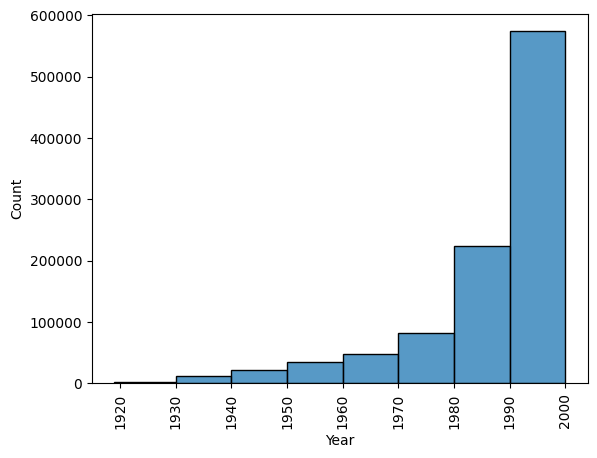

In [30]:
sns.histplot(df_merge['Year'], bins=bins)
plt.xticks(rotation=90)
plt.show()

In [31]:
user_item_matrix= df_merge.pivot_table(index = 'UserID', columns = 'Title', values = 'Rating')
user_item_matrix.fillna(0, inplace=True)

In [32]:
user_item_matrix

Title,"$1,000,000 Duck (1971)",'Night Mother (1986),'Til There Was You (1997),"'burbs, The (1989)",...And Justice for All (1979),1-900 (1994),10 Things I Hate About You (1999),101 Dalmatians (1961),101 Dalmatians (1996),12 Angry Men (1957),...,"Young Poisoner's Handbook, The (1995)",Young Sherlock Holmes (1985),Young and Innocent (1937),Your Friends and Neighbors (1998),Zachariah (1971),"Zed & Two Noughts, A (1985)",Zero Effect (1998),Zero Kelvin (Kjærlighetens kjøtere) (1995),Zeus and Roxanne (1997),eXistenZ (1999)
UserID,,,,,,,,,,,,,,,,,,,,,
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
5,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6036,0.0,3.0,0.0,0.0,0.0,0.0,2.0,4.0,0.0,0.0,...,0.0,3.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0
6037,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,4.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
6038,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


Item-Item based similarity using Pearson Correlation.

In [33]:
def pearson_similarity(movie_title, user_movie_matrix):

    movie_ratings = user_movie_matrix[movie_title]
    similar_movies = user_movie_matrix.corrwith(movie_ratings, method='pearson')
    similar_movies = similar_movies.dropna().sort_values(ascending=False)
    return similar_movies[1:4]

In [34]:
from scipy.stats import pearsonr
def pearsons_similarity(movie_title, user_movie_matrix):
  movie_rating = user_item_matrix[movie_title]
  similarity_scores = {}
  for i in user_item_matrix.columns:
    if i != movie_title:
      j = movie_rating.notna() & user_item_matrix[i].notna()
      if j.sum() > 1:
        similarity_scores[i] = pearsonr(user_item_matrix[i][j], movie_rating[j])[0]

  similarity_scores = pd.Series(similarity_scores).dropna().sort_values(ascending=False)
  return similarity_scores[:3]

In [35]:
print(pearson_similarity('Liar Liar (1997)', user_item_matrix))

Title
Mrs. Doubtfire (1993)                0.499927
Dumb & Dumber (1994)                 0.459601
Ace Ventura: Pet Detective (1994)    0.458654
dtype: float64


In [36]:
print(pearsons_similarity('Liar Liar (1997)', user_item_matrix))

Mrs. Doubtfire (1993)                0.499927
Dumb & Dumber (1994)                 0.459601
Ace Ventura: Pet Detective (1994)    0.458654
dtype: float64


User based collabrative filtering using cosine similarity.

In [37]:
from sklearn.metrics.pairwise import cosine_similarity

user_similarity = cosine_similarity(user_item_matrix)

In [38]:
user_similarity

array([[1.        , 0.09638153, 0.12060981, ..., 0.        , 0.17460369,
        0.13359025],
       [0.09638153, 1.        , 0.1514786 , ..., 0.06611767, 0.0664575 ,
        0.21827563],
       [0.12060981, 0.1514786 , 1.        , ..., 0.12023352, 0.09467506,
        0.13314404],
       ...,
       [0.        , 0.06611767, 0.12023352, ..., 1.        , 0.16171426,
        0.09930008],
       [0.17460369, 0.0664575 , 0.09467506, ..., 0.16171426, 1.        ,
        0.22833237],
       [0.13359025, 0.21827563, 0.13314404, ..., 0.09930008, 0.22833237,
        1.        ]])

In [39]:
user_similarity_df = pd.DataFrame(user_similarity, index=user_item_matrix.index, columns = user_item_matrix.index)

In [40]:
user_similarity_df

UserID,1,2,3,4,5,6,7,8,9,10,...,6031,6032,6033,6034,6035,6036,6037,6038,6039,6040
UserID,,,,,,,,,,,,,,,,,,,,,
1,1.000000,0.096382,0.120610,0.132455,0.090158,0.179222,0.059678,0.138241,0.226148,0.255288,...,0.170588,0.082006,0.069807,0.033663,0.114877,0.186329,0.135979,0.000000,0.174604,0.133590
2,0.096382,1.000000,0.151479,0.171176,0.114394,0.100865,0.305787,0.203337,0.190198,0.226861,...,0.112503,0.091222,0.268565,0.014286,0.183384,0.228241,0.206274,0.066118,0.066457,0.218276
3,0.120610,0.151479,1.000000,0.151227,0.062907,0.074603,0.138332,0.077656,0.126457,0.213655,...,0.092960,0.125864,0.161507,0.000000,0.097308,0.143264,0.107744,0.120234,0.094675,0.133144
4,0.132455,0.171176,0.151227,1.000000,0.045094,0.013529,0.130339,0.100856,0.093651,0.120738,...,0.163629,0.093041,0.382803,0.000000,0.082097,0.170583,0.127464,0.062907,0.064634,0.137968
5,0.090158,0.114394,0.062907,0.045094,1.000000,0.047449,0.126257,0.220817,0.261330,0.117052,...,0.100652,0.035732,0.061806,0.054151,0.179083,0.293365,0.172686,0.020459,0.027689,0.241437
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6036,0.186329,0.228241,0.143264,0.170583,0.293365,0.093583,0.122441,0.227400,0.239607,0.338072,...,0.131294,0.209843,0.186426,0.103431,0.267405,1.000000,0.341462,0.124174,0.219115,0.411891
6037,0.135979,0.206274,0.107744,0.127464,0.172686,0.065788,0.111673,0.144395,0.225055,0.246902,...,0.142309,0.276134,0.129985,0.118749,0.141676,0.341462,1.000000,0.049015,0.252146,0.428240
6038,0.000000,0.066118,0.120234,0.062907,0.020459,0.065711,0.000000,0.019242,0.093470,0.113789,...,0.108837,0.106897,0.040689,0.000000,0.063967,0.124174,0.049015,1.000000,0.161714,0.099300


In [41]:
def user_recommendations(user_id, num_recommendations = 3):
  similar_users = user_similarity_df[user_id].sort_values(ascending=False).iloc[1:num_recommendations+1].index

  similar_users_movies = df_merge[df_merge['UserID'].isin(similar_users)]
  recommended_movies = similar_users_movies.groupby('Title').agg({'Rating' : 'mean'}).sort_values(by = 'Rating', ascending=False).head(num_recommendations)

  return recommended_movies.index.tolist()

In [42]:
user_recommendations(4, 13)

['12 Angry Men (1957)',
 'Bad Boys (1995)',
 "Schindler's List (1993)",
 'Robocop (1987)',
 'Die Hard 2 (1990)',
 'Princess Mononoke, The (Mononoke Hime) (1997)',
 'Drunken Master (Zui quan) (1979)',
 'Enemy of the State (1998)',
 "One Flew Over the Cuckoo's Nest (1975)",
 'Taxi Driver (1976)',
 'Navigator: A Mediaeval Odyssey, The (1988)',
 'Modern Times (1936)',
 'Midnight Run (1988)']

In [43]:
user_item_matrix

Title,"$1,000,000 Duck (1971)",'Night Mother (1986),'Til There Was You (1997),"'burbs, The (1989)",...And Justice for All (1979),1-900 (1994),10 Things I Hate About You (1999),101 Dalmatians (1961),101 Dalmatians (1996),12 Angry Men (1957),...,"Young Poisoner's Handbook, The (1995)",Young Sherlock Holmes (1985),Young and Innocent (1937),Your Friends and Neighbors (1998),Zachariah (1971),"Zed & Two Noughts, A (1985)",Zero Effect (1998),Zero Kelvin (Kjærlighetens kjøtere) (1995),Zeus and Roxanne (1997),eXistenZ (1999)
UserID,,,,,,,,,,,,,,,,,,,,,
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
5,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6036,0.0,3.0,0.0,0.0,0.0,0.0,2.0,4.0,0.0,0.0,...,0.0,3.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0
6037,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,4.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
6038,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


Matrix Factorization using SVD

In [44]:
from scipy.sparse.linalg import svds
user_item_matrix_np = user_item_matrix.fillna(0).values
U, sigma, Vt = svds(user_item_matrix_np, k=100)
sigma = np.diag(sigma)
predicted_ratings = np.dot(np.dot(U, sigma), Vt)
predicted_ratings_df = pd.DataFrame(predicted_ratings, index = user_item_matrix.index, columns = user_item_matrix.columns)

In [45]:
predicted_ratings.shape

(6040, 3706)

In [46]:
predicted_ratings_df

Title,"$1,000,000 Duck (1971)",'Night Mother (1986),'Til There Was You (1997),"'burbs, The (1989)",...And Justice for All (1979),1-900 (1994),10 Things I Hate About You (1999),101 Dalmatians (1961),101 Dalmatians (1996),12 Angry Men (1957),...,"Young Poisoner's Handbook, The (1995)",Young Sherlock Holmes (1985),Young and Innocent (1937),Your Friends and Neighbors (1998),Zachariah (1971),"Zed & Two Noughts, A (1985)",Zero Effect (1998),Zero Kelvin (Kjærlighetens kjøtere) (1995),Zeus and Roxanne (1997),eXistenZ (1999)
UserID,,,,,,,,,,,,,,,,,,,,,
1,-0.017295,0.093524,0.082611,0.084234,-0.026206,0.006905,-0.134164,1.290121,0.515611,0.564588,...,-0.005566,-0.402327,0.062575,0.100294,-0.012043,-0.010085,0.379229,-0.001126,0.023033,0.022479
2,-0.046974,0.084964,-0.080660,0.184107,0.127813,0.003515,0.076862,-0.382115,-0.187420,1.108406,...,-0.035451,0.110988,0.023653,-0.128809,0.016569,-0.017450,-0.321861,-0.018836,-0.022152,0.004564
3,0.007644,-0.044547,-0.028510,0.111466,-0.050816,0.001800,0.084777,0.190751,0.239934,-0.080196,...,0.042306,0.196128,-0.005010,-0.052260,0.014446,0.003950,0.015947,0.000148,-0.033749,-0.215865
4,-0.058278,0.023767,-0.026122,0.003330,-0.014909,-0.001822,-0.000958,0.122361,0.080116,0.462138,...,0.050103,-0.035645,0.012481,-0.010275,0.012455,-0.016919,-0.085970,-0.000017,-0.009223,0.135702
5,0.091334,0.035338,0.002675,0.083342,-0.286391,0.000847,0.265638,-0.017868,0.049912,0.104146,...,0.440375,-0.076322,-0.057116,0.400026,0.004220,0.033378,1.018128,-0.047035,0.016244,0.972452
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6036,0.193261,0.906932,-0.069640,0.152254,0.692122,0.001053,2.377071,2.794027,-0.138490,0.549830,...,0.763824,1.217029,0.095034,0.794768,0.023019,0.626507,1.726721,0.139614,0.175181,3.662070
6037,0.065486,0.155806,0.085535,0.235624,0.530688,-0.003959,0.147667,-0.081679,-0.067016,3.581049,...,-0.206517,0.185188,0.108398,-0.005940,-0.001357,-0.163804,0.488453,-0.049423,0.016293,-0.013571
6038,0.006549,0.017405,-0.022241,0.021700,-0.183477,0.001079,-0.060381,-0.006511,-0.032853,-0.159194,...,0.017447,-0.008233,-0.002905,-0.008301,-0.002836,0.022927,-0.018263,0.008896,0.006861,0.017775


In [47]:
def get_svd_reccommendations(user_id, num_reccomendations=3):
  user_predictions = predicted_ratings_df.loc[user_id].sort_values(ascending=False).head(num_reccomendations)
  return user_predictions.index.to_list()

In [48]:
get_svd_reccommendations(1, 3)

['Toy Story (1995)', "Schindler's List (1993)", 'Saving Private Ryan (1998)']

In [49]:
user_item_matrix.shape

(6040, 3706)

In [50]:
predicted_ratings.shape

(6040, 3706)

In [51]:
actual_ratings_np = user_item_matrix.to_numpy()
predicted_ratings_np = predicted_ratings_df.to_numpy()

In [52]:
mask = actual_ratings_np>0
actual_ratings_nonzero = actual_ratings_np[mask]
predicted_ratings_nonzero = predicted_ratings_np[mask]

In [53]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error
mae = mean_absolute_error(actual_ratings_nonzero, predicted_ratings_nonzero)
mse = np.sqrt(mean_squared_error(actual_ratings_nonzero, predicted_ratings_nonzero))
mape = np.mean(np.abs((actual_ratings_nonzero - predicted_ratings_nonzero) / actual_ratings_nonzero)) * 100
print(f"MAE :{mae}")
print(f"RMSE :{mse}")
print(f"MAPE : {mape}")

MAE :1.7307280668927585
RMSE :2.0662532700952054
MAPE : 49.367941603973456


Matrix Factorization using SVD from surprise library.

In [54]:
!pip install scikit-surprise

In [55]:
!pip install numpy==1.23.5
!pip install --no-cache-dir scikit-surprise

In [56]:
from surprise import SVD
from surprise import Dataset, Reader
from surprise.model_selection import cross_validate

reader = Reader(rating_scale = (1,5))
data = Dataset.load_from_df(df_merge[['UserID', 'MovieID', 'Rating']], reader)
algo = SVD(n_factors=50, reg_all=0.1)
cross_validate(algo, data, cv=5, verbose=True)

Evaluating RMSE, MAE of algorithm SVD on 5 split(s).

                  Fold 1  Fold 2  Fold 3  Fold 4  Fold 5  Mean    Std     
RMSE (testset)    0.8968  0.8984  0.8992  0.8983  0.8970  0.8979  0.0009  
MAE (testset)     0.7117  0.7131  0.7137  0.7133  0.7122  0.7128  0.0007  
Fit time          23.83   15.41   14.48   13.91   14.09   16.35   3.78    
Test time         2.84    2.21    2.02    2.55    3.11    2.55    0.40    


{'test_rmse': array([0.89675206, 0.89839487, 0.89923948, 0.89827352, 0.89700364]),
 'test_mae': array([0.71169757, 0.71308992, 0.71367042, 0.71326237, 0.71222222]),
 'fit_time': (23.834558725357056,
  15.409549474716187,
  14.47839879989624,
  13.910844564437866,
  14.093099594116211),
 'test_time': (2.8436203002929688,
  2.2108073234558105,
  2.017770528793335,
  2.55440354347229,
  3.1074278354644775)}

In [115]:
from surprise.model_selection import train_test_split

trainset, testset = train_test_split(data, test_size=0.2, random_state=42)

# Instantiate and train the SVD model
algo = SVD(n_factors=50, reg_all=0.1)
algo.fit(trainset)

# Predict ratings for the testset
predictions = algo.test(testset)

# Extract actual and predicted ratings
actual = [pred.r_ui for pred in predictions]
predicted = [pred.est for pred in predictions]

# Compute MAPE: Only consider cases where actual rating is not zero
mape = np.mean([abs(a - p) / a for a, p in zip(actual, predicted) if a != 0]) * 100

print(f"MAPE: {mape:.2f}%")

MAPE: 27.98%


In [57]:
trainset = data.build_full_trainset()
algo.fit(trainset)

In [59]:
user_id = 10
movie_id = 300

predicted_rating = algo.predict(uid =user_id, iid = movie_id)
print(predicted_rating.est)

4.064014196326718


In [65]:
all_movies_id = df_merge['MovieID'].unique()
predictions = [algo.predict(uid = user_id, iid = i) for i in all_movies_id]

In [68]:
top_movies =sorted(predictions, key = lambda x:x.est, reverse=True)[:10]
top_movies_id = [i.iid for i in top_movies]
print(top_movies_id)

[318, 2905, 527, 2762, 668, 3338, 745, 1148, 2503, 3147]


Embedding Based Similarity.

In [69]:
user_embeddings = U
item_embeddings = Vt.T

In [73]:
user_embeddings.shape

(6040, 100)

In [75]:
item_embeddings.shape

(3706, 100)

In [71]:
item_similarity = cosine_similarity(item_embeddings)
user_similarity_svd = cosine_similarity(user_embeddings)

In [77]:
from sklearn.decomposition import PCA
pca = PCA(n_components = 2)
reduced_embeddings = pca.fit_transform(item_similarity)

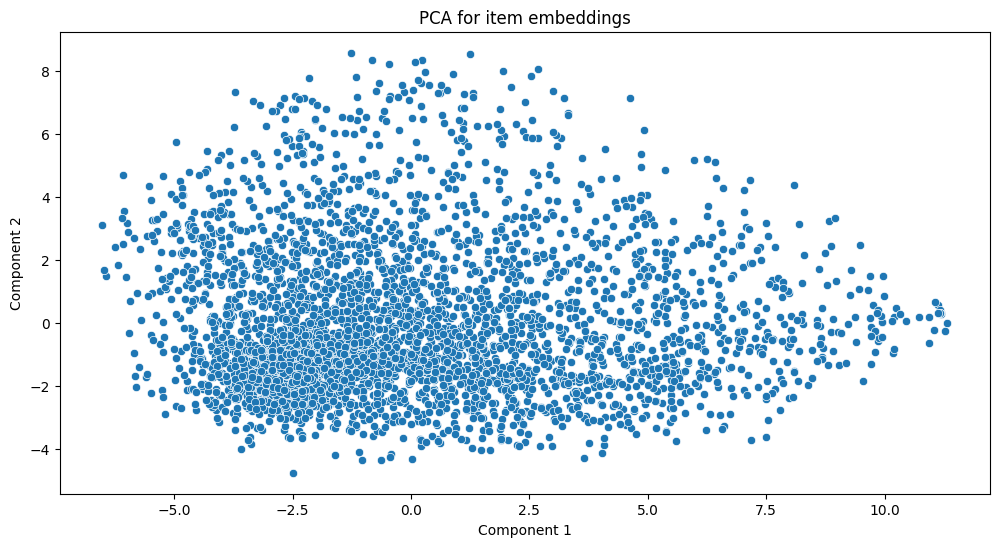

In [85]:
plt.figure(figsize=(12,6))
sns.scatterplot(x = reduced_embeddings[:,0],y= reduced_embeddings[:,1])
plt.title('PCA for item embeddings')
plt.xlabel('Component 1')
plt.ylabel('Component 2')
plt.show()

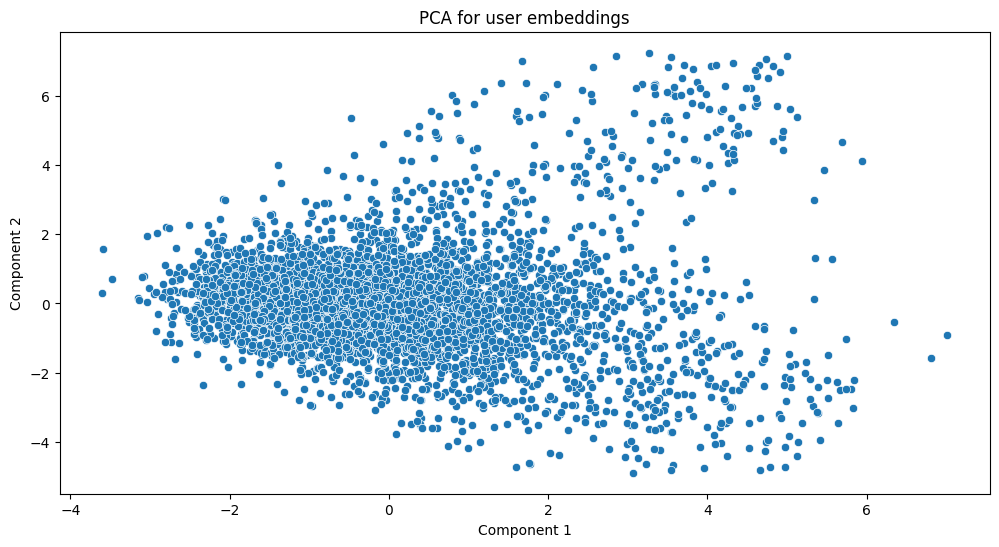

In [84]:
reduced_embeddings_user = pca.fit_transform(user_similarity_svd)
plt.figure(figsize=(12,6))
sns.scatterplot(x = reduced_embeddings_user[:,0],y =  reduced_embeddings_user[:,1])
plt.title('PCA for user embeddings')
plt.xlabel('Component 1')
plt.ylabel('Component 2')
plt.show()

1.The age group of 18-24 years rated the most number of movies.

2.Graduate profession has the most number of ratings given.

3.True, Most number of movies rated are by gender 'Male'.

4.90's decade has the most number of movies released.

5.American Beauty released in 1999 is the modt rated movie in the dataset.

6.Top 3 movies similar to 'Liar Liar' on item-based approach are:

a..Ace Ventura:Pet Detective.

b.Dumb and Dumber.

c.Mrs. Doubtfire

7.User-Based and Item Based.

8.Pearson Co-efficient ranges between -1 and +1, Cosine Similarity ranges between 0 and +1.

9.RMSE = 0.89 (From SVD model evaluation)
MAE = 28.2%.

10.Based on sparse matrix representation,
row indices = [0,1,1], column indices = [0,0,1], values = [1,3,7].